In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.join(current_dir, '..', '..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from sklearn.svm import LinearSVC
from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier


In [26]:
def make_meshgrid(x, y, h=0.01):
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, xy, **params):
    Z = clf.predict(xy)
    Z = Z.reshape(xx.shape)
    return ax.contourf(xx, yy, Z, **params)


## 1. Create Dataset

Dataset: 790 points, Classes: [-1.  1.]
Distribution: {-1.0: 574, 1.0: 216}
Exact classifier accuracy: 97.47%


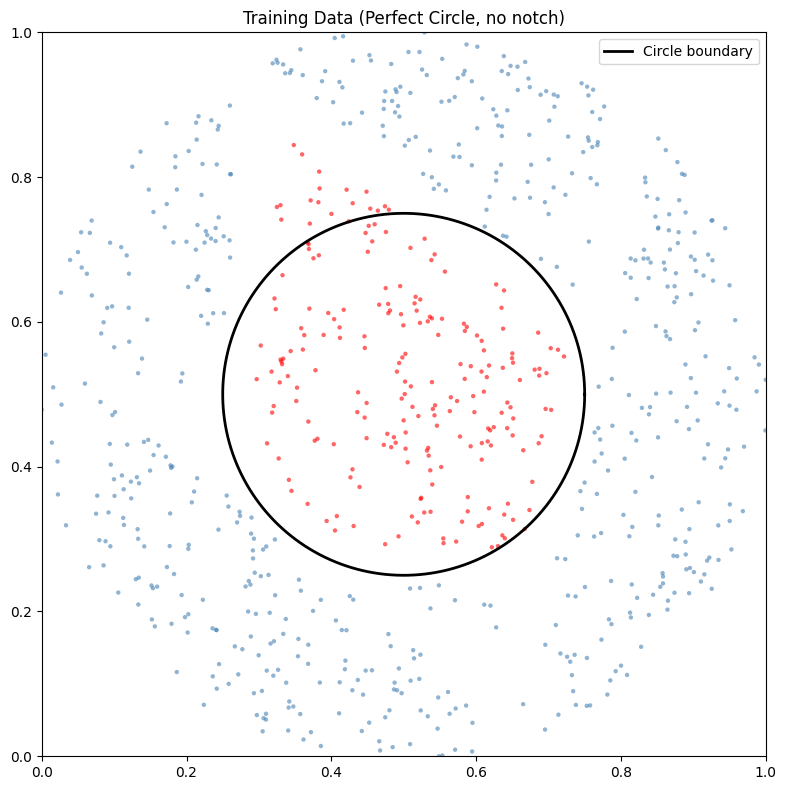

In [27]:
from sklearn.metrics import accuracy_score

CIRCLE_CENTER = np.array([0.5, 0.5])
CIRCLE_RADIUS = 0.25


def shape_classify(pts):
    pts = np.atleast_2d(pts)
    dist = np.linalg.norm(pts - CIRCLE_CENTER, axis=1)
    return np.where(dist < CIRCLE_RADIUS, 1.0, -1.0)

class ExactClassifier:
    def predict(self, pts):
        return shape_classify(pts)

    def predict_proba(self, pts):
        pts = np.atleast_2d(pts)
        dist = np.linalg.norm(pts - CIRCLE_CENTER, axis=1)
        p_inside = 1.0 / (1.0 + np.exp(50.0 * (dist - CIRCLE_RADIUS)))
        return np.column_stack([1.0 - p_inside, p_inside])

    def fit(self, X, y):
        return self

dataset_path = '../tests/datasets/dataset.npz'
# REGENERATE = True

# if REGENERATE or not os.path.exists(dataset_path):
#     np.random.seed(42)
#     n_samples = 50000
#     raw_pts = np.column_stack([np.random.uniform(0, 1, n_samples),
#                                np.random.uniform(0, 1, n_samples)])
#     raw_labels = shape_classify(raw_pts)
#     inside_idx = np.where(raw_labels == 1.0)[0]
#     outside_idx = np.where(raw_labels == -1.0)[0]
#     n_min = min(len(inside_idx), len(outside_idx), 400)
#     keep = np.concatenate([inside_idx[:n_min], outside_idx[:n_min]])
#     np.random.shuffle(keep)
#     np.savez(dataset_path, X=raw_pts[keep], y=raw_labels[keep])
#     print(f"Generated {dataset_path}")

data = np.load(dataset_path)
X, y = data['X'], data['y']

clf = ExactClassifier()
print(f"Dataset: {X.shape[0]} points, Classes: {np.unique(y)}")
print(f"Distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Exact classifier accuracy: {accuracy_score(y, clf.predict(X)):.2%}")

theta = np.linspace(0.0, 2.0 * np.pi, 200)
circle_xy = np.column_stack([CIRCLE_CENTER[0] + CIRCLE_RADIUS * np.cos(theta),
                             CIRCLE_CENTER[1] + CIRCLE_RADIUS * np.sin(theta)])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1],
           c=['red' if l == 1 else 'steelblue' for l in y],
           s=10, alpha=0.6, edgecolors='none')
ax.plot(circle_xy[:, 0], circle_xy[:, 1], 'k-', linewidth=2, label='Circle boundary')
ax.set_title('Training Data (Perfect Circle, no notch)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Build Model


In [28]:
C = 10000

root_vertices = [
    (0, 0),
    (2, 0),
    (0, 2)
]

subdivision_levels = 4
model = SimplexTreeClassifier(
    vertices=root_vertices,
    classifier=LinearSVC(C=C),
    subdivision_levels=subdivision_levels,
)
model.fit(X, y)

x_min, x_max = -0.05, 1.5
y_min, y_max = -0.05, 1.5
xx, yy = make_meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

print(f"Model built with {len(model.leaf_simplexes)} leaf simplices")


Model built with 81 leaf simplices


## 3. Find Simplices to Remove

- **Non-convex**: Adjacent crossing simplices where the average point falls on wrong side
- **Same-side**: All siblings on same side of decision boundary

In [29]:
weights = model.classifier.coef_[0]
intercept = model.classifier.intercept_[0]
# Epsilon is now a fraction (0-1) of the distance from meeting point to external crossing
# 0.30 = 30% of the way toward the external crossing
EPSILON = 0.30

nonconvex_simplex_keys = model.find_nonconvex_simplexes(epsilon=EPSILON)
same_side_simplex_keys = model.find_same_side_simplices()
combined_keys = nonconvex_simplex_keys.union(same_side_simplex_keys)

print(f"Non-convex simplices: {len(nonconvex_simplex_keys)}")
print(f"Same-side simplices: {len(same_side_simplex_keys)}")
print(f"Combined (union): {len(combined_keys)}")
print(f"Leaves before removal: {len(model.tree.get_leaves())}")
model.tree.print_tree(show_only_splitting_points=False)    

embedding = model.transform(X)
decision_values = model.classifier.decision_function(embedding)
print(decision_values.shape)



Non-convex simplices: 24
Same-side simplices: 39
Combined (union): 63
Leaves before removal: 81
└── [0] vertices: [0, 1, 2]
    ├── [1] vertices: [1, 2, 3]
    │   ├── [2] vertices: [2, 3, 4]
    │   │   ├── [3] vertices: [3, 4, 5]
    │   │   │   ├── vertices: [4, 5, 6]
    │   │   │   ├── vertices: [3, 5, 6]
    │   │   │   └── vertices: [3, 4, 6]
    │   │   ├── [4] vertices: [2, 4, 5]
    │   │   │   ├── vertices: [4, 5, 7]
    │   │   │   ├── vertices: [2, 5, 7]
    │   │   │   └── vertices: [2, 4, 7]
    │   │   └── [5] vertices: [2, 3, 5]
    │   │       ├── vertices: [3, 5, 8]
    │   │       ├── vertices: [2, 5, 8]
    │   │       └── vertices: [2, 3, 8]
    │   ├── [6] vertices: [1, 3, 4]
    │   │   ├── [7] vertices: [3, 4, 9]
    │   │   │   ├── vertices: [4, 9, 10]
    │   │   │   ├── vertices: [3, 9, 10]
    │   │   │   └── vertices: [3, 4, 10]
    │   │   ├── [8] vertices: [1, 4, 9]
    │   │   │   ├── vertices: [4, 9, 11]
    │   │   │   ├── vertices: [1, 9, 11]
    │  

## Option 1 : 
- take weights of simplex
- create hyperplanes from it 
- see the plane
- see the arrow pointing in 90 degrees from it 


For each leaf simplex:

1. Take the weights on its vertices (projected back to the original 2D plane via `PlaneEquation`) giving coefficients `[a, b, c]` such that inside the simplex `decision(x, y) = a·x + b·y + c`.
2. The hyperplane is `a·x + b·y + c = 0` — we clip it to the simplex polygon and draw the segment in black.
3. The arrow is the unit normal `(a, b) / ||(a, b)||` drawn from the midpoint of the segment (perpendicular to the line, pointing toward the positive class).

### Iteration #1

Found: 24 non-convex, 39 same-side, 63 combined


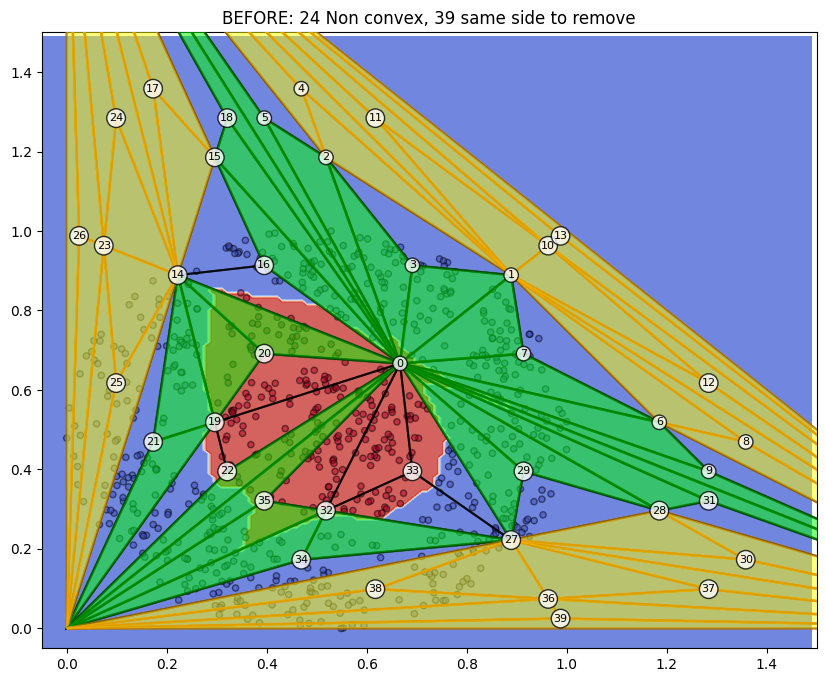

In [30]:
nonconvex_simplex_keys = model.find_nonconvex_simplexes(epsilon=EPSILON)
same_side_simplex_keys = model.find_same_side_simplices()
combined_keys = nonconvex_simplex_keys.union(same_side_simplex_keys)

print(f"Found: {len(nonconvex_simplex_keys)} non-convex, {len(same_side_simplex_keys)} same-side, {len(combined_keys)} combined")

fig, ax = plt.subplots(figsize=(10, 8))
xy = model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
plot_contours(ax, model.classifier, xx, yy, xy, cmap=plt.cm.coolwarm, alpha=0.8)
for boundary in model.get_simplex_boundaries():
    if len(boundary) >= 3:
        closed = boundary + [boundary[0]]
        bx, by = zip(*closed)
        ax.plot(bx, by, 'k', linestyle='-', linewidth=1.5, alpha=0.7)
for leaf in model.tree.get_leaves():
    simplex_key = frozenset(leaf.vertex_indices)
    is_nonconvex = simplex_key in nonconvex_simplex_keys
    is_same_side = simplex_key in same_side_simplex_keys
    if is_nonconvex and is_same_side:
        color, edge = 'purple', 'darkviolet'
    elif is_nonconvex:
        color, edge = 'lime', 'green'
    elif is_same_side:
        color, edge = 'yellow', 'orange'
    else:
        continue
    vertices = np.array(leaf.vertices)
    poly = patches.Polygon(vertices, closed=True, facecolor=color, alpha=0.5, edgecolor=edge, linewidth=2, zorder=6)
    ax.add_patch(poly)
for idx, center in model.tree.get_splitting_points():
    ax.annotate(str(idx), center, fontsize=8, ha='center', va='center', 
                bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', edgecolor='black', alpha=0.8), zorder=10)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k', alpha=0.5)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title(f"BEFORE: {len(nonconvex_simplex_keys)} Non convex, {len(same_side_simplex_keys)} same side to remove")
plt.show()

Removed 26. Leaves remaining: 29


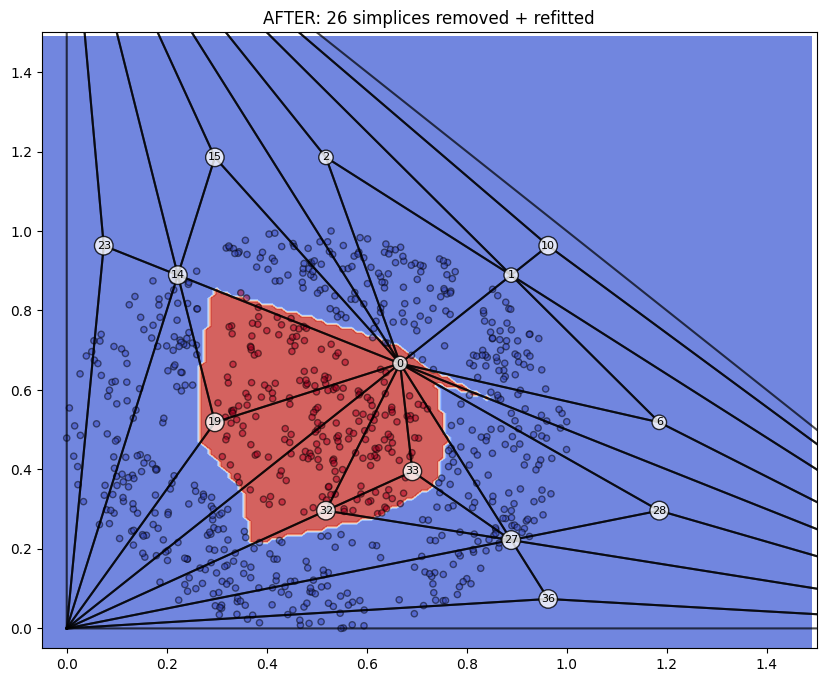

In [31]:
if len(combined_keys) > 0:
    removed_count = 0
    for simplex_key in combined_keys:
        if model.tree.remove_by_leaf_key(simplex_key):
            removed_count += 1
    model._build_node_lookup()
    model.fit(X, y)
    print(f"Removed {removed_count}. Leaves remaining: {len(model.tree.get_leaves())}")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    xy = model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
    plot_contours(ax, model.classifier, xx, yy, xy, cmap=plt.cm.coolwarm, alpha=0.8)
    for leaf in model.tree.get_leaves():
        vertices = leaf.get_vertices_as_tuples()
        if len(vertices) >= 3:
            closed = vertices + [vertices[0]]
            bx, by = zip(*closed)
            ax.plot(bx, by, 'k', linestyle='-', linewidth=1.5, alpha=0.7)
    for idx, center in model.tree.get_splitting_points():
        ax.annotate(str(idx), center, fontsize=8, ha='center', va='center', 
                    bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', edgecolor='black', alpha=0.8), zorder=10)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k', alpha=0.5)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"AFTER: {removed_count} simplices removed + refitted")
    plt.show()
else:
    print("Nothing to remove - converged!")

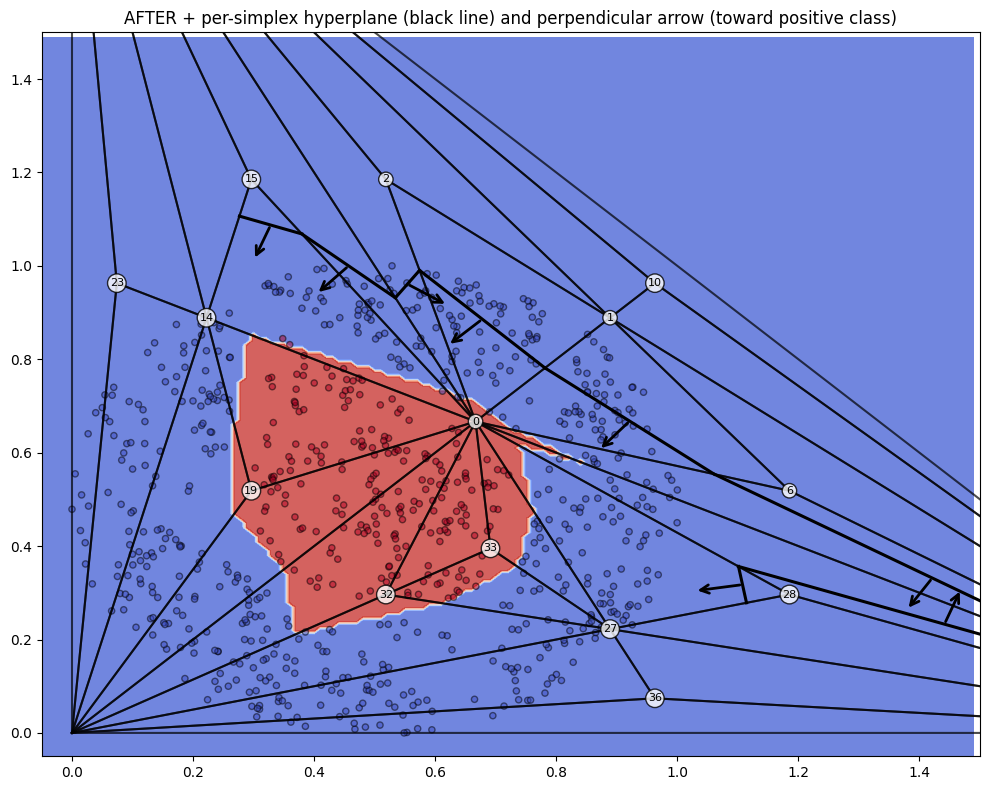

In [32]:
from in2D.classifying.classes.utilss.convexity_check import find_crossing_on_edge

fig, ax = plt.subplots(figsize=(10, 8))
xy_after = model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
plot_contours(ax, model.classifier, xx, yy, xy_after, cmap=plt.cm.coolwarm, alpha=0.8)

for leaf in model.tree.get_leaves():
    vertices = leaf.get_vertices_as_tuples()
    if len(vertices) >= 3:
        closed = vertices + [vertices[0]]
        bx, by = zip(*closed)
        ax.plot(bx, by, 'k', linestyle='-', linewidth=1.5, alpha=0.7)

plane_equations = model.compute_svm_plane_equations()
arrow_length = 0.08

for info in plane_equations:
    vertices = info['vertices']
    a, b, c = info['coefficients']

    grad_norm = np.hypot(a, b)
    if grad_norm < 1e-12:
        continue

    crossings = []
    n = len(vertices)
    for i in range(n):
        p1 = np.array(vertices[i], dtype=float)
        p2 = np.array(vertices[(i + 1) % n], dtype=float)
        crossing = find_crossing_on_edge(info['coefficients'], p1, p2)
        if crossing is not None:
            crossings.append(crossing)
    if len(crossings) < 2:
        continue

    p0, p1 = crossings[0], crossings[1]
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
            color='black', linewidth=2.2, zorder=11)

    midpoint = 0.5 * (p0 + p1)
    normal = np.array([a, b]) / grad_norm  # perpendicular to the line, toward positive class
    dx, dy = normal * arrow_length
    ax.annotate(
        '', xy=(midpoint[0] + dx, midpoint[1] + dy), xytext=(midpoint[0], midpoint[1]),
        arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=15),
        zorder=12,
    )

for idx, center in model.tree.get_splitting_points():
    ax.annotate(str(idx), center, fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', edgecolor='black', alpha=0.8),
                zorder=10)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k', alpha=0.5)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("AFTER + per-simplex hyperplane (black line) and perpendicular arrow (toward positive class)")
plt.tight_layout()
plt.show()

## Option 2:
- The planes that created by the classifier 
- i want to check if a simplex contains a classifier hyperplane 
- if it does - 

- if it doesnt : 
it goes up the tree to the closest levels and check if the unclels or further - are holding a plane and if more then one - do an avarage of all 
- and when you found what the does hold - create the vertical arrow pointing from it 

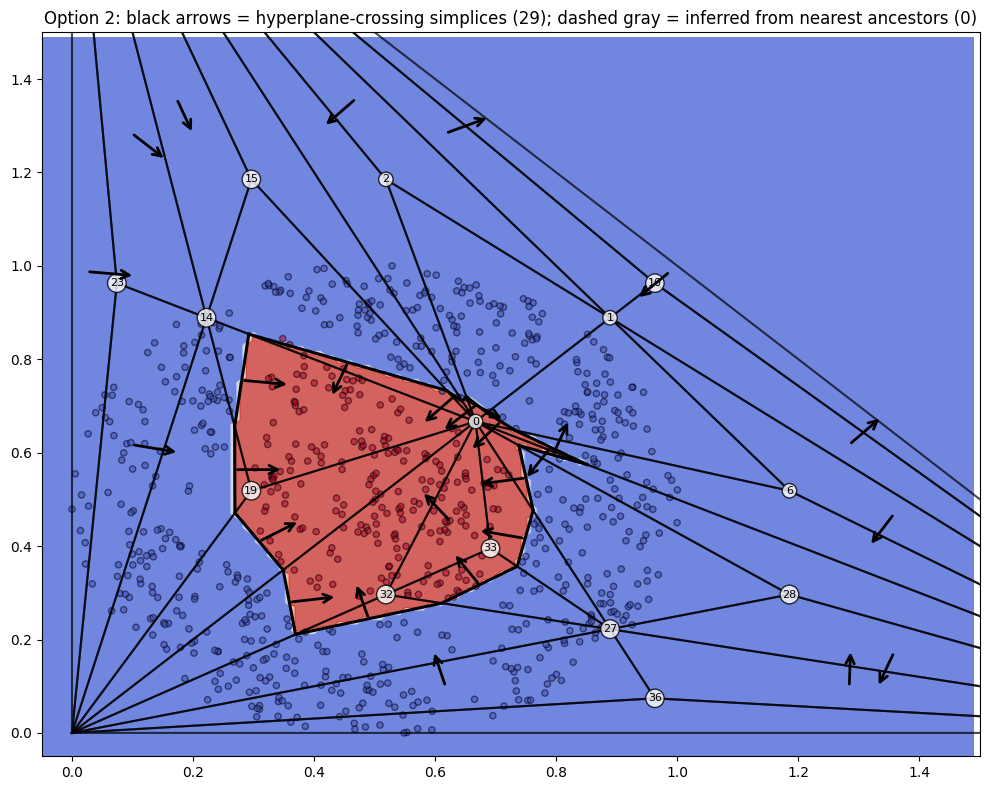

Direct (crossing) simplices: 29
Inferred (from tree walk-up): 0
Skipped (no nearby crossing found): 0


In [33]:
from in2D.classifying.classes.utilss.plane_equation import PlaneEquation
from in2D.classifying.classes.utilss.convexity_check import find_crossing_on_edge


weights_v2, intercept_v2 = model.get_weights_and_intercept()


def _plane_coeffs(leaf):
    """(a, b, c) such that decision(x, y) = a*x + b*y + c inside this simplex,
    computed with the intercept (so the zero-level matches the SVM boundary)."""
    pe = PlaneEquation(leaf)
    return pe.compute_plane_from_weights(weights_v2, intercept_v2)


def _simplex_crosses(leaf):
    vals = [weights_v2[idx] + intercept_v2 for idx in leaf.vertex_indices]
    return any(v > 0 for v in vals) and any(v < 0 for v in vals)


def _edge_crossings(vertices, coeffs):
    pts = []
    n = len(vertices)
    for i in range(n):
        p1 = np.array(vertices[i], dtype=float)
        p2 = np.array(vertices[(i + 1) % n], dtype=float)
        pt = find_crossing_on_edge(coeffs, p1, p2)
        if pt is not None:
            pts.append(pt)
    return pts


def _leaf_descendants(node):
    if node._is_leaf():
        yield node
    else:
        for child in node.children:
            yield from _leaf_descendants(child)


def _find_nearest_crossing_planes(leaf):
    """Walk up the tree. At each ancestor, inspect sibling subtrees for leaves
    that cross the decision boundary. Return all their plane coefficients at
    the first level that yields any crossings (siblings, then uncles, etc.)."""
    current = leaf
    while current.parent is not None:
        parent = current.parent
        found = []
        for sibling in parent.children:
            if sibling is current:
                continue
            for desc in _leaf_descendants(sibling):
                if _simplex_crosses(desc):
                    found.append(_plane_coeffs(desc))
        if found:
            return found
        current = parent
    return []


def _simplex_area(vertices):
    """Compute area of a polygon given its vertices."""
    verts = np.array(vertices)
    n = len(verts)
    area = 0.0
    for i in range(n):
        j = (i + 1) % n
        area += verts[i][0] * verts[j][1]
        area -= verts[j][0] * verts[i][1]
    return abs(area) / 2.0


def _random_point_in_triangle(v0, v1, v2):
    """Sample a uniformly random point inside a triangle."""
    r1, r2 = np.random.random(), np.random.random()
    if r1 + r2 > 1:
        r1, r2 = 1 - r1, 1 - r2
    return (1 - r1 - r2) * v0 + r1 * v1 + r2 * v2


fig, ax = plt.subplots(figsize=(10, 8))
xy_after = model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
plot_contours(ax, model.classifier, xx, yy, xy_after, cmap=plt.cm.coolwarm, alpha=0.8)

for leaf in model.tree.get_leaves():
    vertices = leaf.get_vertices_as_tuples()
    if len(vertices) >= 3:
        closed = vertices + [vertices[0]]
        bx, by = zip(*closed)
        ax.plot(bx, by, 'k', linestyle='-', linewidth=1.5, alpha=0.7)

arrow_length = 0.08
arrow_area_threshold = 0.005
max_arrows_per_leaf = 1

direct_count = 0
inferred_count = 0
skipped_count = 0

for leaf in model.tree.get_leaves():
    verts = leaf.get_vertices_as_tuples()
    if len(verts) < 3:
        continue

    centroid = np.mean(np.array(verts), axis=0)

    a, b, c = _plane_coeffs(leaf)
    grad_norm = np.hypot(a, b)

    if _simplex_crosses(leaf):
        if grad_norm < 1e-12:
            skipped_count += 1
            continue

        crossings = _edge_crossings(verts, (a, b, c))
        if len(crossings) >= 2:
            p0, p1 = crossings[0], crossings[1]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color='black', linewidth=2.2, zorder=11)
            origin = 0.5 * (p0 + p1)
        else:
            origin = centroid

        normal = np.array([a, b]) / grad_norm
        dx, dy = normal * arrow_length
        ax.annotate(
            '', xy=(origin[0] + dx, origin[1] + dy), xytext=(origin[0], origin[1]),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=15),
            zorder=12,
        )
        direct_count += 1
    elif grad_norm > 1e-12:
        normal = np.array([a, b]) / grad_norm
        dx, dy = normal * arrow_length

        area = _simplex_area(verts)
        n_arrows = min(max(1, int(area / arrow_area_threshold)), max_arrows_per_leaf)
        v = np.array(verts)
        for _ in range(n_arrows):
            if n_arrows == 1:
                origin = centroid
            else:
                origin = _random_point_in_triangle(v[0], v[1], v[2])
            ax.annotate(
                '', xy=(origin[0] + dx, origin[1] + dy), xytext=(origin[0], origin[1]),
                arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=15),
                zorder=12,
            )
        direct_count += n_arrows
    else:
        planes = _find_nearest_crossing_planes(leaf)
        normals = []
        for (a, b, _c) in planes:
            nrm = np.hypot(a, b)
            if nrm > 1e-12:
                normals.append(np.array([a, b]) / nrm)
        if not normals:
            skipped_count += 1
            continue

        avg = np.mean(normals, axis=0)
        avg_norm = np.linalg.norm(avg)
        if avg_norm < 1e-12:
            skipped_count += 1
            continue
        avg /= avg_norm

        dx, dy = avg * arrow_length
        ax.annotate(
            '', xy=(centroid[0] + dx, centroid[1] + dy), xytext=(centroid[0], centroid[1]),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=15),
            zorder=12,
        )
        inferred_count += 1

for idx, center in model.tree.get_splitting_points():
    ax.annotate(str(idx), center, fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', edgecolor='black', alpha=0.8),
                zorder=10)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k', alpha=0.5)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title(
    f"Option 2: black arrows = hyperplane-crossing simplices ({direct_count}); "
    f"dashed gray = inferred from nearest ancestors ({inferred_count})"
)
plt.tight_layout()
plt.show()

print(f"Direct (crossing) simplices: {direct_count}")
print(f"Inferred (from tree walk-up): {inferred_count}")
print(f"Skipped (no nearby crossing found): {skipped_count}")

Found: 9 non-convex, 9 same-side, 18 combined


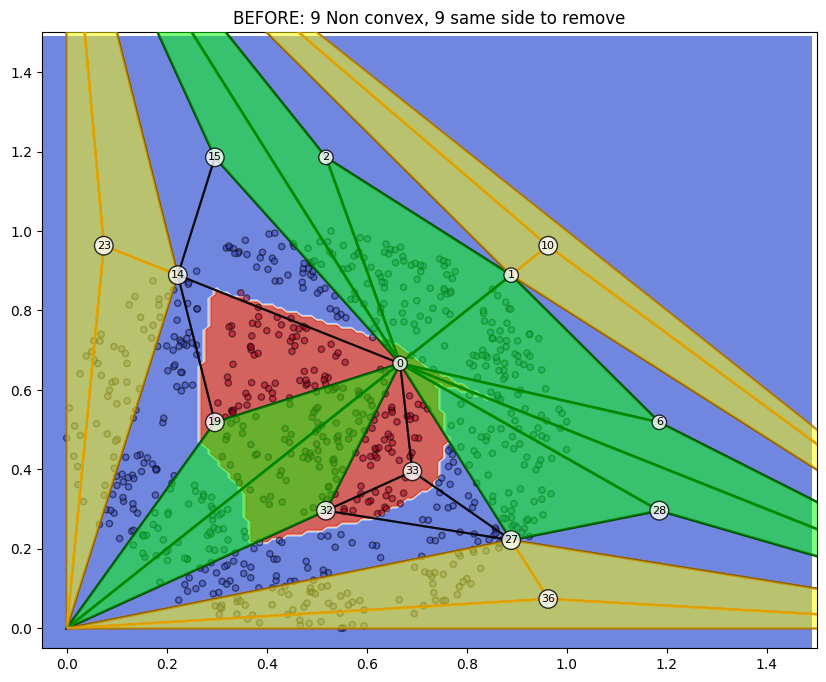

In [34]:
nonconvex_simplex_keys = model.find_nonconvex_simplexes(epsilon=EPSILON)
same_side_simplex_keys = model.find_same_side_simplices()
combined_keys = nonconvex_simplex_keys.union(same_side_simplex_keys)

print(f"Found: {len(nonconvex_simplex_keys)} non-convex, {len(same_side_simplex_keys)} same-side, {len(combined_keys)} combined")

fig, ax = plt.subplots(figsize=(10, 8))
xy = model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
plot_contours(ax, model.classifier, xx, yy, xy, cmap=plt.cm.coolwarm, alpha=0.8)
for boundary in model.get_simplex_boundaries():
    if len(boundary) >= 3:
        closed = boundary + [boundary[0]]
        bx, by = zip(*closed)
        ax.plot(bx, by, 'k', linestyle='-', linewidth=1.5, alpha=0.7)
for leaf in model.tree.get_leaves():
    simplex_key = frozenset(leaf.vertex_indices)
    is_nonconvex = simplex_key in nonconvex_simplex_keys
    is_same_side = simplex_key in same_side_simplex_keys
    if is_nonconvex and is_same_side:
        color, edge = 'purple', 'darkviolet'
    elif is_nonconvex:
        color, edge = 'lime', 'green'
    elif is_same_side:
        color, edge = 'yellow', 'orange'
    else:
        continue
    vertices = np.array(leaf.vertices)
    poly = patches.Polygon(vertices, closed=True, facecolor=color, alpha=0.5, edgecolor=edge, linewidth=2, zorder=6)
    ax.add_patch(poly)
for idx, center in model.tree.get_splitting_points():
    ax.annotate(str(idx), center, fontsize=8, ha='center', va='center', 
                bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', edgecolor='black', alpha=0.8), zorder=10)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k', alpha=0.5)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title(f"BEFORE: {len(nonconvex_simplex_keys)} Non convex, {len(same_side_simplex_keys)} same side to remove")
plt.show()

Removed 8. Leaves remaining: 13


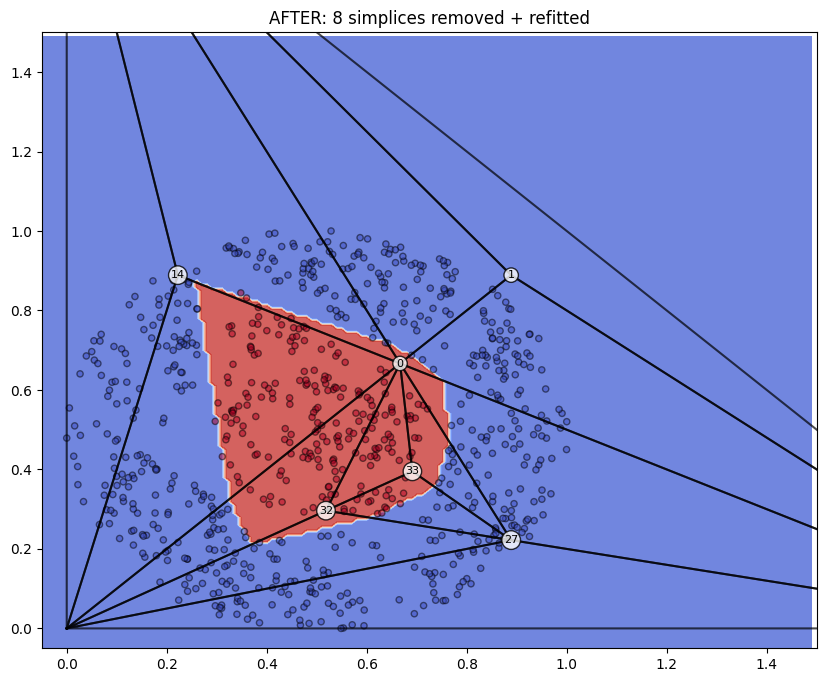

In [35]:
if len(combined_keys) > 0:
    removed_count = 0
    for simplex_key in combined_keys:
        if model.tree.remove_by_leaf_key(simplex_key):
            removed_count += 1
    model._build_node_lookup()
    model.fit(X, y)
    print(f"Removed {removed_count}. Leaves remaining: {len(model.tree.get_leaves())}")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    xy = model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
    plot_contours(ax, model.classifier, xx, yy, xy, cmap=plt.cm.coolwarm, alpha=0.8)
    for leaf in model.tree.get_leaves():
        vertices = leaf.get_vertices_as_tuples()
        if len(vertices) >= 3:
            closed = vertices + [vertices[0]]
            bx, by = zip(*closed)
            ax.plot(bx, by, 'k', linestyle='-', linewidth=1.5, alpha=0.7)
    for idx, center in model.tree.get_splitting_points():
        ax.annotate(str(idx), center, fontsize=8, ha='center', va='center', 
                    bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', edgecolor='black', alpha=0.8), zorder=10)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k', alpha=0.5)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"AFTER: {removed_count} simplices removed + refitted")
    plt.show()
else:
    print("Nothing to remove - converged!")

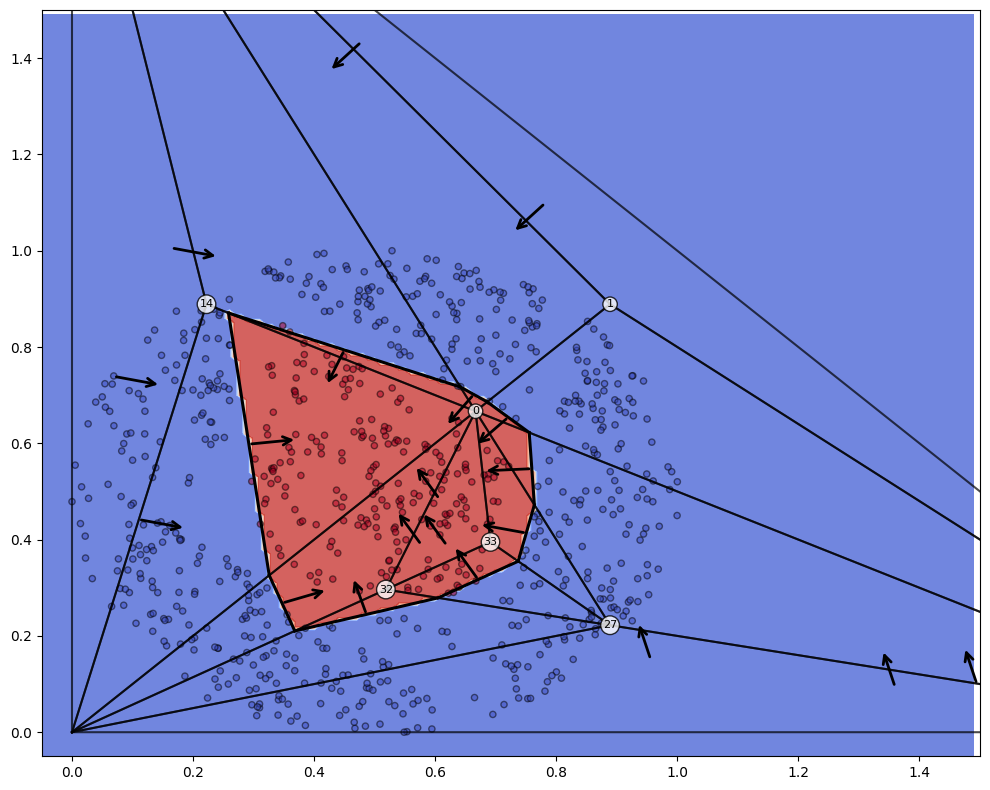

Direct (crossing) simplices: 21
Inferred (from tree walk-up): 0
Skipped (no nearby crossing found): 0


In [36]:
from in2D.classifying.classes.utilss.plane_equation import PlaneEquation
from in2D.classifying.classes.utilss.convexity_check import find_crossing_on_edge


weights_v2, intercept_v2 = model.get_weights_and_intercept()


def _plane_coeffs(leaf):
    """(a, b, c) such that decision(x, y) = a*x + b*y + c inside this simplex,
    computed with the intercept (so the zero-level matches the SVM boundary)."""
    pe = PlaneEquation(leaf)
    return pe.compute_plane_from_weights(weights_v2, intercept_v2)


def _simplex_crosses(leaf):
    vals = [weights_v2[idx] + intercept_v2 for idx in leaf.vertex_indices]
    return any(v > 0 for v in vals) and any(v < 0 for v in vals)


def _edge_crossings(vertices, coeffs):
    pts = []
    n = len(vertices)
    for i in range(n):
        p1 = np.array(vertices[i], dtype=float)
        p2 = np.array(vertices[(i + 1) % n], dtype=float)
        pt = find_crossing_on_edge(coeffs, p1, p2)
        if pt is not None:
            pts.append(pt)
    return pts


def _leaf_descendants(node):
    if node._is_leaf():
        yield node
    else:
        for child in node.children:
            yield from _leaf_descendants(child)


def _find_nearest_crossing_planes(leaf):
    """Walk up the tree. At each ancestor, inspect sibling subtrees for leaves
    that cross the decision boundary. Return all their plane coefficients at
    the first level that yields any crossings (siblings, then uncles, etc.)."""
    current = leaf
    while current.parent is not None:
        parent = current.parent
        found = []
        for sibling in parent.children:
            if sibling is current:
                continue
            for desc in _leaf_descendants(sibling):
                if _simplex_crosses(desc):
                    found.append(_plane_coeffs(desc))
        if found:
            return found
        current = parent
    return []


def _simplex_area(vertices):
    """Compute area of a polygon given its vertices."""
    verts = np.array(vertices)
    n = len(verts)
    area = 0.0
    for i in range(n):
        j = (i + 1) % n
        area += verts[i][0] * verts[j][1]
        area -= verts[j][0] * verts[i][1]
    return abs(area) / 2.0


def _random_point_in_triangle(v0, v1, v2):
    """Sample a uniformly random point inside a triangle."""
    r1, r2 = np.random.random(), np.random.random()
    if r1 + r2 > 1:
        r1, r2 = 1 - r1, 1 - r2
    return (1 - r1 - r2) * v0 + r1 * v1 + r2 * v2


fig, ax = plt.subplots(figsize=(10, 8))
xy_after = model.transform(np.vstack([xx.ravel(), yy.ravel()]).T)
plot_contours(ax, model.classifier, xx, yy, xy_after, cmap=plt.cm.coolwarm, alpha=0.8)

for leaf in model.tree.get_leaves():
    vertices = leaf.get_vertices_as_tuples()
    if len(vertices) >= 3:
        closed = vertices + [vertices[0]]
        bx, by = zip(*closed)
        ax.plot(bx, by, 'k', linestyle='-', linewidth=1.5, alpha=0.7)

arrow_length = 0.08
arrow_area_threshold = 0.005
max_arrows_per_leaf = 3

direct_count = 0
inferred_count = 0
skipped_count = 0

for leaf in model.tree.get_leaves():
    verts = leaf.get_vertices_as_tuples()
    if len(verts) < 3:
        continue

    centroid = np.mean(np.array(verts), axis=0)

    a, b, c = _plane_coeffs(leaf)
    grad_norm = np.hypot(a, b)

    if _simplex_crosses(leaf):
        if grad_norm < 1e-12:
            skipped_count += 1
            continue

        crossings = _edge_crossings(verts, (a, b, c))
        if len(crossings) >= 2:
            p0, p1 = crossings[0], crossings[1]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color='black', linewidth=2.2, zorder=11)
            origin = 0.5 * (p0 + p1)
        else:
            origin = centroid

        normal = np.array([a, b]) / grad_norm
        dx, dy = normal * arrow_length
        ax.annotate(
            '', xy=(origin[0] + dx, origin[1] + dy), xytext=(origin[0], origin[1]),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=15),
            zorder=12,
        )
        direct_count += 1
    elif grad_norm > 1e-12:
        normal = np.array([a, b]) / grad_norm
        dx, dy = normal * arrow_length

        area = _simplex_area(verts)
        n_arrows = min(max(1, int(area / arrow_area_threshold)), max_arrows_per_leaf)
        v = np.array(verts)
        for _ in range(n_arrows):
            if n_arrows == 1:
                origin = centroid
            else:
                origin = _random_point_in_triangle(v[0], v[1], v[2])
            ax.annotate(
                '', xy=(origin[0] + dx, origin[1] + dy), xytext=(origin[0], origin[1]),
                arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=15),
                zorder=12,
            )
        direct_count += n_arrows
    else:
        planes = _find_nearest_crossing_planes(leaf)
        normals = []
        for (a, b, _c) in planes:
            nrm = np.hypot(a, b)
            if nrm > 1e-12:
                normals.append(np.array([a, b]) / nrm)
        if not normals:
            skipped_count += 1
            continue

        avg = np.mean(normals, axis=0)
        avg_norm = np.linalg.norm(avg)
        if avg_norm < 1e-12:
            skipped_count += 1
            continue
        avg /= avg_norm

        dx, dy = avg * arrow_length
        ax.annotate(
            '', xy=(centroid[0] + dx, centroid[1] + dy), xytext=(centroid[0], centroid[1]),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=15),
            zorder=12,
        )
        inferred_count += 1

for idx, center in model.tree.get_splitting_points():
    ax.annotate(str(idx), center, fontsize=8, ha='center', va='center',
                bbox=dict(boxstyle='circle,pad=0.2', facecolor='white', edgecolor='black', alpha=0.8),
                zorder=10)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k', alpha=0.5)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

print(f"Direct (crossing) simplices: {direct_count}")
print(f"Inferred (from tree walk-up): {inferred_count}")
print(f"Skipped (no nearby crossing found): {skipped_count}")